# Fit st and fpt with uncertainties in their slopes and breakpoint  
- Use this to find uncertainties in early slopes of FPT and ST fit  
- Then do T test to compare it with early slope of FN  

In [1]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress 
from scipy.optimize import curve_fit
from scipy import stats
from scipy import linalg
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap

In [2]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Piecewise linear fit define function 

In [3]:
data_folder = Path('../../data/results/calculate_final_params')
files=glob.glob(f"{data_folder}/final_*.pkl")
print(files)

['..\\..\\data\\results\\calculate_final_params\\final_bla.pkl', '..\\..\\data\\results\\calculate_final_params\\final_enti.pkl', '..\\..\\data\\results\\calculate_final_params\\final_fn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lha.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lsc.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mob.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mop.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mos.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mrn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_orb.pkl', '..\\..\\data\\results\\calculate_final_params\\final_peri.pkl', '..\\..\\data\\results\\calculate_final_params\\final_pir.pkl', '..\\..\\data\\results\\calculate_final_params\\final_re.pkl']


#### Old piecewise linear fit function: It uses 'linear ' method. We got better fit and all errors by 'non linear' method  

In [ ]:
# def fit_piecewiseLinear(data, ax, label):
#     # intervals as this is the time when state changes from another state
    
#     intervals = data.copy()
#     # print(f'original values: {intervals}')
#     intervals = np.sort(intervals)
#     n = len(intervals)

#     # CCDF: P(T > t)
#     ccdf = 1.0 - np.arange(1, n + 1) / n

#     # Remove zero values (log undefined)
#     mask = ccdf > 0
#     intervals = intervals[mask]
#     ccdf = ccdf[mask]

#     # Log of CCDF
#     log_ccdf = np.log(ccdf)

#     x = intervals
#     y = log_ccdf

#     # Fit piecewise linear model with 2 segments
#     my_pwlf = pwlf.PiecewiseLinFit(x, y)
#     res = my_pwlf.fit(2)

#     # Breakpoints returned by pwlf.fit
#     breakpoints = res   # e.g. [min_x, breakpoint, max_x]

#     # First segment is between breakpoints[0] and breakpoints[1]
#     # finding out interval values which contributed to slope 1
#     mask_slope1 = (x >= breakpoints[0]) & (x <= breakpoints[1])
#     entries_slope1 = x[mask_slope1]

#     # print("Entries belonging to slope 1:", entries_slope1.tolist())
#      # Entries corresponding to slope 2 (between res[1] and res[2])
#     mask2 = (x >= res[1]) & (x <= res[2])
#     entries_slope2 = x[mask2]

#     # Predict
#     y_hat = my_pwlf.predict(x)

#     # Plot
#     ax.scatter(x, y, label="Data")
#     ax.plot(x, y_hat, 'r', label="Piecewise fit")
#     ax.set_ylabel("log P(T > t)")
#     ax.set_title(f"Log-CCDF breakpoint ~ {round(res[1])} {label}")
#     ax.legend()

#     # Slopes of the fitted lines
#     slopes = my_pwlf.calc_slopes()
#     se_betas=my_pwlf.standard_errors()
    

#     print("Slopes of fitted lines:", slopes)
#     print("SE for early slopes",se_betas)

#     # Optionally annotate slopes on the plot
#     for i, slope in enumerate(slopes):
#         ax.text(x.mean(), y_hat.mean() - i*0.5, f"Slope {i+1}: {slope:.3f}", color="blue")

#     return {'exp':slopes, 'joint': round(res[1]),'slope_1_entries':entries_slope1.tolist(),'s2':entries_slope2.tolist(),'s1_se':se_betas[1]}


New fit functin which gives all errors

In [ ]:

def fit_piecewiseLinear(data, ax, label):
    # 1. Prepare Data (CCDF logic)
    intervals = np.sort(data.copy())
    n = len(intervals)
    ccdf = 1.0 - np.arange(1, n + 1) / n
    mask = ccdf > 0
    x = intervals[mask]
    y = np.log(ccdf[mask])

    # 2. Fit the model
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breakpoints = my_pwlf.fit(2)  # [min_x, joint, max_x]
    joint = breakpoints[1]
    
    # 3. Calculate Joint Error (Standard Error of the breakpoint)
    # The 'non-linear' method treats the breakpoint as a parameter to find its SE
    try:
        se_all = my_pwlf.standard_errors(method='non-linear')
        se_joint = se_all[-1] # The last value is the SE of the interior joint
    except:
        se_joint = np.nan # Fallback if non-linear method isn't supported in your version

    # 4. Manually Construct Regression Matrix A
    # Column 0: Intercept (constant 1s)
    # Column 1: First slope component (x - min_x)
    # Column 2: Second slope component (x - joint, but only where x > joint)
    col0 = np.ones(len(x))
    col1 = x - breakpoints[0]
    col2 = np.maximum(0, x - joint)
    A = np.column_stack([col0, col1, col2])

    # 5. Calculate Slope Errors using Covariance
    # Degree of freedom = n_samples - n_parameters (3 for a 2-segment fit)
    dof = len(x) - 3
    sigma_sq = my_pwlf.ssr / dof
    
    # Covariance Matrix = sigma_sq * (A^T * A)^-1
    # pinv is used for numerical stability
    cov_beta = sigma_sq * linalg.pinv(np.dot(A.T, A))

    # Slope 1 = Beta 1
    se_slope1 = np.sqrt(cov_beta[1, 1])
    
    # Slope 2 = Beta 1 + Beta 2
    # Var(S2) = Var(B1) + Var(B2) + 2*Cov(B1, B2)
    var_slope2 = cov_beta[1, 1] + cov_beta[2, 2] + 2 * cov_beta[1, 2]
    se_slope2 = np.sqrt(max(0, var_slope2))

    # 6. Plotting and Results
    y_hat = my_pwlf.predict(x)
    slopes = my_pwlf.calc_slopes()

    ax.scatter(x, y, alpha=0.3, label="Data")
    ax.plot(x, y_hat, 'r', linewidth=2, label="Piecewise fit")
    ax.axvline(joint, color='green', linestyle='--', alpha=0.6, 
               label=f"Joint: {joint:.1f} ± {se_joint:.1f}")
    
    ax.set_title(f"Fit for {label}")
    ax.legend()

    print(f"--- Results for {label} ---")
    print(f"Joint:   {joint:.4f} ± {se_joint:.4f}")
    print(f"Slope 1: {slopes[0]:.4f} ± {se_slope1:.4f}")
    print(f"Slope 2: {slopes[1]:.4f} ± {se_slope2:.4f}")

    return {
        'slopes': slopes.tolist(),
        'slopes_se': [se_slope1, se_slope2],
        'joint': joint,
        'joint_se': se_joint
    }

### part fpt

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_fpt_bla ---
Joint:   396.7473 ± 4.1879
Slope 1: -0.0028 ± 0.0001
Slope 2: -0.0167 ± 0.0005
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_fpt_enti ---
Joint:   525.8769 ± 2.1108
Slope 1: -0.0041 ± 0.0001
Slope 2: -0.0409 ± 0.0013
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_fpt_fn ---
Joint:   504.3640 ± 2.0562
Slope 1: -0.0043 ± 0.0001
Slope 2: -0.0335 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_fpt_lha ---
Joint:   526.3608 ± 3.0638
Slope 1: -0.0040 ± 0.0001
Slope 2: -0.0483 ± 0.0022
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_fpt_lsc ---
Joint:   526.4390 ± 1.3938
Slope 1: -0.0047 ± 0.0001
Slope 2: -0.0521 ± 0.0015
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

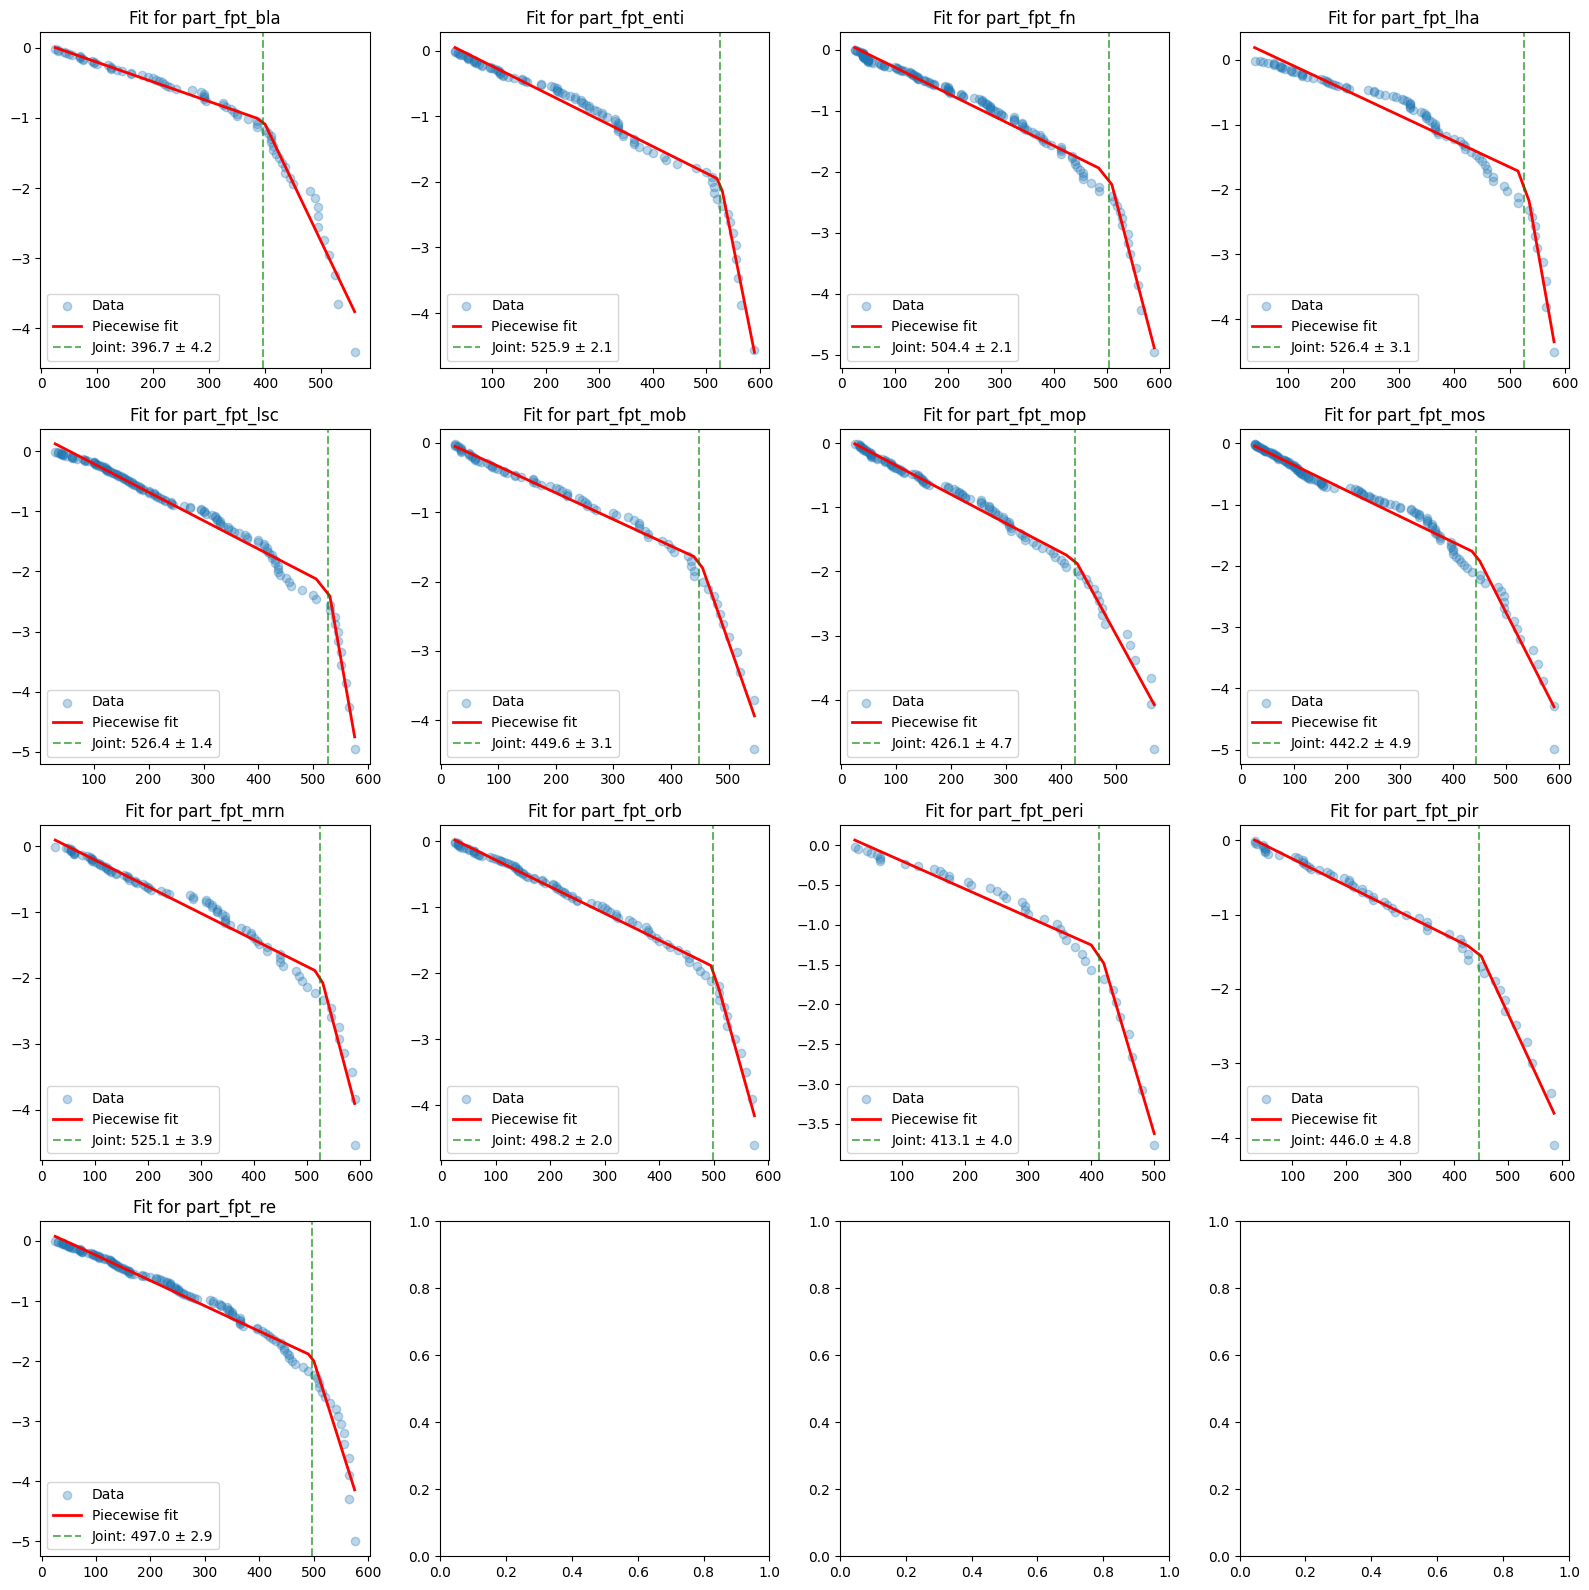

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_joint_se={}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_fpt = [x for x in params[1]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(part_fpt, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_joint[nw] = p['joint']
    dict_joint_se[nw]=p['joint_se']
    dict_slp1_se[nw]=p['slopes_se'][0]

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [17]:
dict_slp1_se

{'bla': 0.00013333688900138722,
 'enti': 7.654491970197502e-05,
 'fn': 6.27307344071776e-05,
 'lha': 0.00013386333616110816,
 'lsc': 6.773143533036703e-05,
 'mob': 7.896589684963015e-05,
 'mop': 8.26759787104747e-05,
 'mos': 7.911890178545498e-05,
 'mrn': 9.960984202194108e-05,
 'orb': 5.992592138328281e-05,
 'peri': 0.00015528715720235171,
 'pir': 9.548073859279774e-05,
 're': 8.168054151536047e-05}

Applying T test comparing every with FN

In [ ]:
def compare_slopes(m1, se1, m2, se2):
    """
    Returns the t-statistic and p-value for the comparison of two slopes.
    """
    
    # Calculate the t-statistic
    t_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    
    # Calculate p-value (two-tailed)
    # Using normal distribution (Z-test) as a standard approximation for large N
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return t_stat, p_value

In [ ]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -10.1286, P-value: 0.0000
T-statistic: -2.2219, P-value: 0.0263
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -1.9065, P-value: 0.0566
T-statistic: 4.8508, P-value: 0.0000
T-statistic: -4.5438, P-value: 0.0000
T-statistic: 2.0979, P-value: 0.0359
T-statistic: -0.9982, P-value: 0.3182
T-statistic: -2.1174, P-value: 0.0342
T-statistic: -2.8708, P-value: 0.0041
T-statistic: -4.6617, P-value: 0.0000
T-statistic: -6.0687, P-value: 0.0000
T-statistic: -0.7199, P-value: 0.4716


In [10]:
nw

['bla', 'enti', 'lsc', 'mob', 'mop', 'mrn', 'orb', 'peri', 'pir']

Compare joints

In [ ]:
jnw=[]
for s,se,label in zip(list(dict_joint.values()),list(dict_joint_se.values()),dict_joint.keys()):
    t, p = compare_slopes(dict_joint['fn'], dict_joint_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        jnw.append(label)
    else:
        pass

T-statistic: 23.0667, P-value: 0.0000
T-statistic: -7.3004, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -5.9615, P-value: 0.0000
T-statistic: -8.8866, P-value: 0.0000
T-statistic: 14.8181, P-value: 0.0000
T-statistic: 15.3643, P-value: 0.0000
T-statistic: 11.6683, P-value: 0.0000
T-statistic: -4.7153, P-value: 0.0000
T-statistic: 2.1463, P-value: 0.0319
T-statistic: 20.3161, P-value: 0.0000
T-statistic: 11.2236, P-value: 0.0000
T-statistic: 2.0748, P-value: 0.0380


Storing above data for fig5j  

In [12]:
part_fpt={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw,'s_j':jnw}
part_fpt

{'slp1': {'bla': -0.0027967386398349433,
  'enti': -0.0040693887747667735,
  'fn': -0.004289282311310031,
  'lha': -0.004007438622119341,
  'lsc': -0.004737098848395709,
  'mob': -0.003831048702223402,
  'mop': -0.0045070057097631325,
  'mos': -0.004188497857288297,
  'mrn': -0.004040032426754003,
  'orb': -0.004040234081883639,
  'peri': -0.0035085717612979325,
  'pir': -0.003595955284550633,
  're': -0.00421513516943396},
 'bp': {'bla': 396.74729963279833,
  'enti': 525.876868276345,
  'fn': 504.3639650777093,
  'lha': 526.3608116277198,
  'lsc': 526.4390010356492,
  'mob': 449.59716294235665,
  'mop': 426.06257394065125,
  'mos': 442.227708420612,
  'mrn': 525.1155500581197,
  'orb': 498.1538565741633,
  'peri': 413.0730442786993,
  'pir': 445.99081185328316,
  're': 496.99768296617435},
 's_nw': ['bla', 'enti', 'lsc', 'mob', 'mop', 'mrn', 'orb', 'peri', 'pir'],
 's_j': ['bla',
  'enti',
  'lha',
  'lsc',
  'mob',
  'mop',
  'mos',
  'mrn',
  'orb',
  'peri',
  'pir',
  're']}

### FPT full

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for full_fpt_bla ---
Joint:   421.6844 ± 8.6593
Slope 1: -0.0017 ± 0.0007
Slope 2: -0.0156 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for full_fpt_enti ---
Joint:   365.1332 ± 7.7421
Slope 1: -0.0025 ± 0.0002
Slope 2: -0.0119 ± 0.0004
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for full_fpt_fn ---
Joint:   482.9726 ± 4.9630
Slope 1: -0.0035 ± 0.0002
Slope 2: -0.0238 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for full_fpt_lha ---
Joint:   420.3211 ± 9.3858
Slope 1: -0.0020 ± 0.0003
Slope 2: -0.0166 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for full_fpt_lsc ---
Joint:   402.3380 ± 5.6184
Slope 1: -0.0024 ± 0.0002
Slope 2: -0.0166 ± 0.0006
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

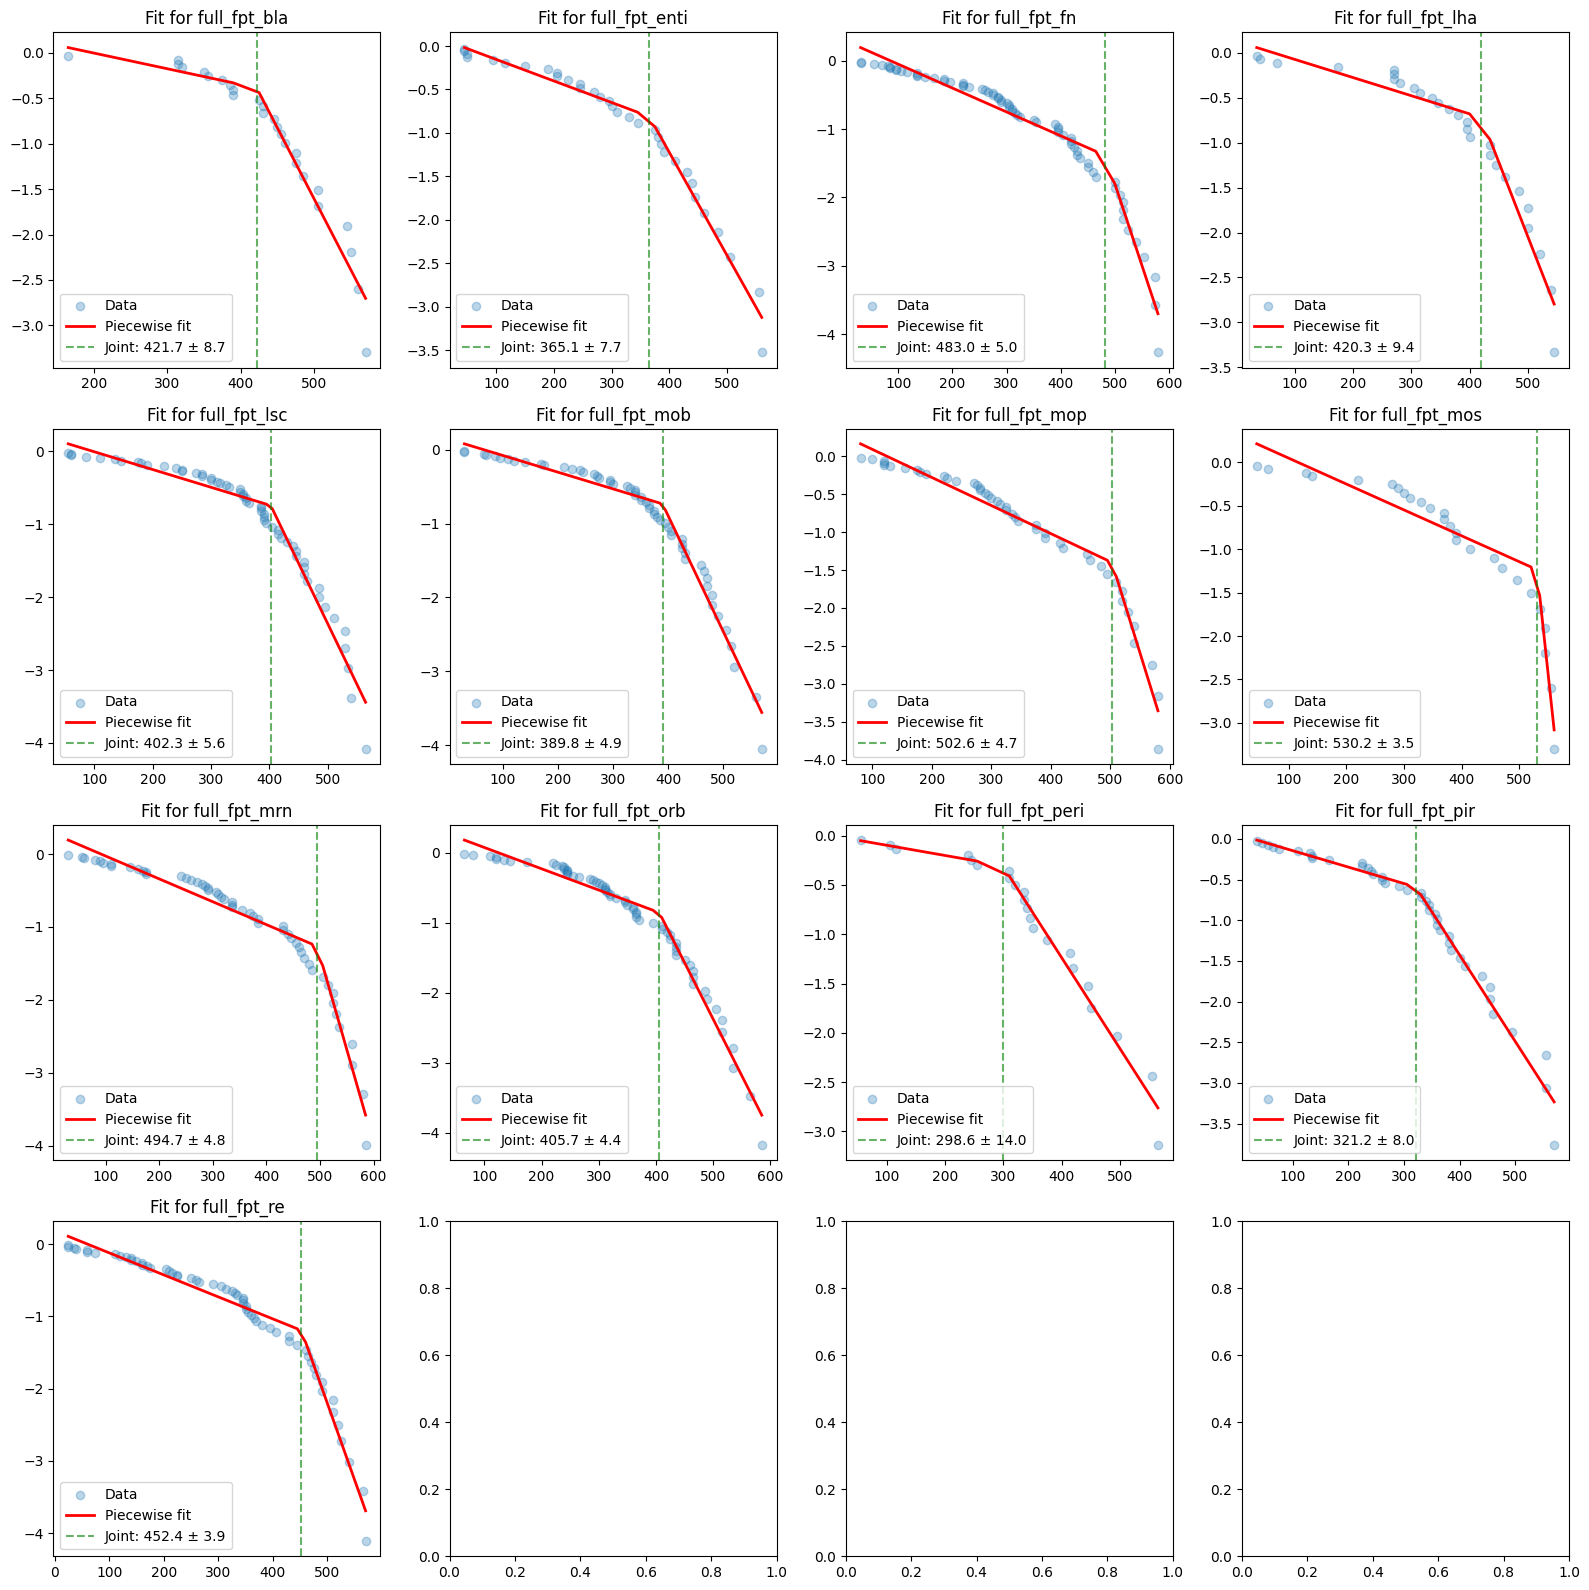

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_joint_se={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_fpt = [x for x in params[2]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(full_fpt, ax, f"full_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_joint[nw] = p['joint']
    dict_joint_se[nw]=p['joint_se']
    dict_slp1_se[nw]=p['slopes_se'][0]

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


t test

In [ ]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -2.5531, P-value: 0.0107
T-statistic: -3.9486, P-value: 0.0001
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -3.9059, P-value: 0.0001
T-statistic: -3.7866, P-value: 0.0002
T-statistic: -5.1536, P-value: 0.0000
T-statistic: 0.8869, P-value: 0.3751
T-statistic: -1.5429, P-value: 0.1229
T-statistic: -1.5736, P-value: 0.1156
T-statistic: -1.8273, P-value: 0.0677
T-statistic: -5.4128, P-value: 0.0000
T-statistic: -5.3108, P-value: 0.0000
T-statistic: -2.1671, P-value: 0.0302


compare joints

In [ ]:
jnw=[]
for s,se,label in zip(list(dict_joint.values()),list(dict_joint_se.values()),dict_joint.keys()):
    t, p = compare_slopes(dict_joint['fn'], dict_joint_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        jnw.append(label)
    else:
        pass

T-statistic: 6.1406, P-value: 0.0000
T-statistic: 12.8139, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 5.9010, P-value: 0.0000
T-statistic: 10.7563, P-value: 0.0000
T-statistic: 13.3579, P-value: 0.0000
T-statistic: -2.8699, P-value: 0.0041
T-statistic: -7.8042, P-value: 0.0000
T-statistic: -1.6900, P-value: 0.0910
T-statistic: 11.6297, P-value: 0.0000
T-statistic: 12.4048, P-value: 0.0000
T-statistic: 17.1937, P-value: 0.0000
T-statistic: 4.8371, P-value: 0.0000


Storing above for fig5j

In [17]:
full_fpt={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw,'s_j':jnw}
full_fpt

{'slp1': {'bla': -0.0017281431470113047,
  'enti': -0.002480980665481094,
  'fn': -0.003485253030402766,
  'lha': -0.00202091068125252,
  'lsc': -0.0024360520271518356,
  'mob': -0.002258856297900321,
  'mop': -0.0036947221939079055,
  'mos': -0.00298577410027598,
  'mrn': -0.003135861469466485,
  'orb': -0.003042955468615255,
  'peri': -0.0010355558820930762,
  'pir': -0.0020175217649611413,
  're': -0.0030488011258202703},
 'bp': {'bla': 421.6843654753038,
  'enti': 365.1331639418863,
  'fn': 482.9726186813084,
  'lha': 420.32111158764405,
  'lsc': 402.3380491961294,
  'mob': 389.78049406563684,
  'mop': 502.6110711334354,
  'mos': 530.1868705323217,
  'mrn': 494.6867644434714,
  'orb': 405.7141639238101,
  'peri': 298.5746609123515,
  'pir': 321.2410918161189,
  're': 452.42547947589026},
 's_nw': ['bla', 'enti', 'lha', 'lsc', 'mob', 'peri', 'pir', 're'],
 's_j': ['bla',
  'enti',
  'lha',
  'lsc',
  'mob',
  'mop',
  'mos',
  'orb',
  'peri',
  'pir',
  're']}

### Part ST

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_fpt_bla ---
Joint:   212.0487 ± 3.2484
Slope 1: -0.0186 ± 0.0002
Slope 2: -0.0038 ± 0.0002
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_fpt_enti ---
Joint:   103.7242 ± 1.2625
Slope 1: -0.0287 ± 0.0005
Slope 2: -0.0081 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_fpt_fn ---
Joint:   157.0444 ± 3.9876
Slope 1: -0.0242 ± 0.0003
Slope 2: -0.0137 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_fpt_lha ---
Joint:   125.9128 ± 2.1867
Slope 1: -0.0324 ± 0.0006
Slope 2: -0.0079 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_fpt_lsc ---
Joint:   111.4980 ± 1.8734
Slope 1: -0.0228 ± 0.0004
Slope 2: -0.0079 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

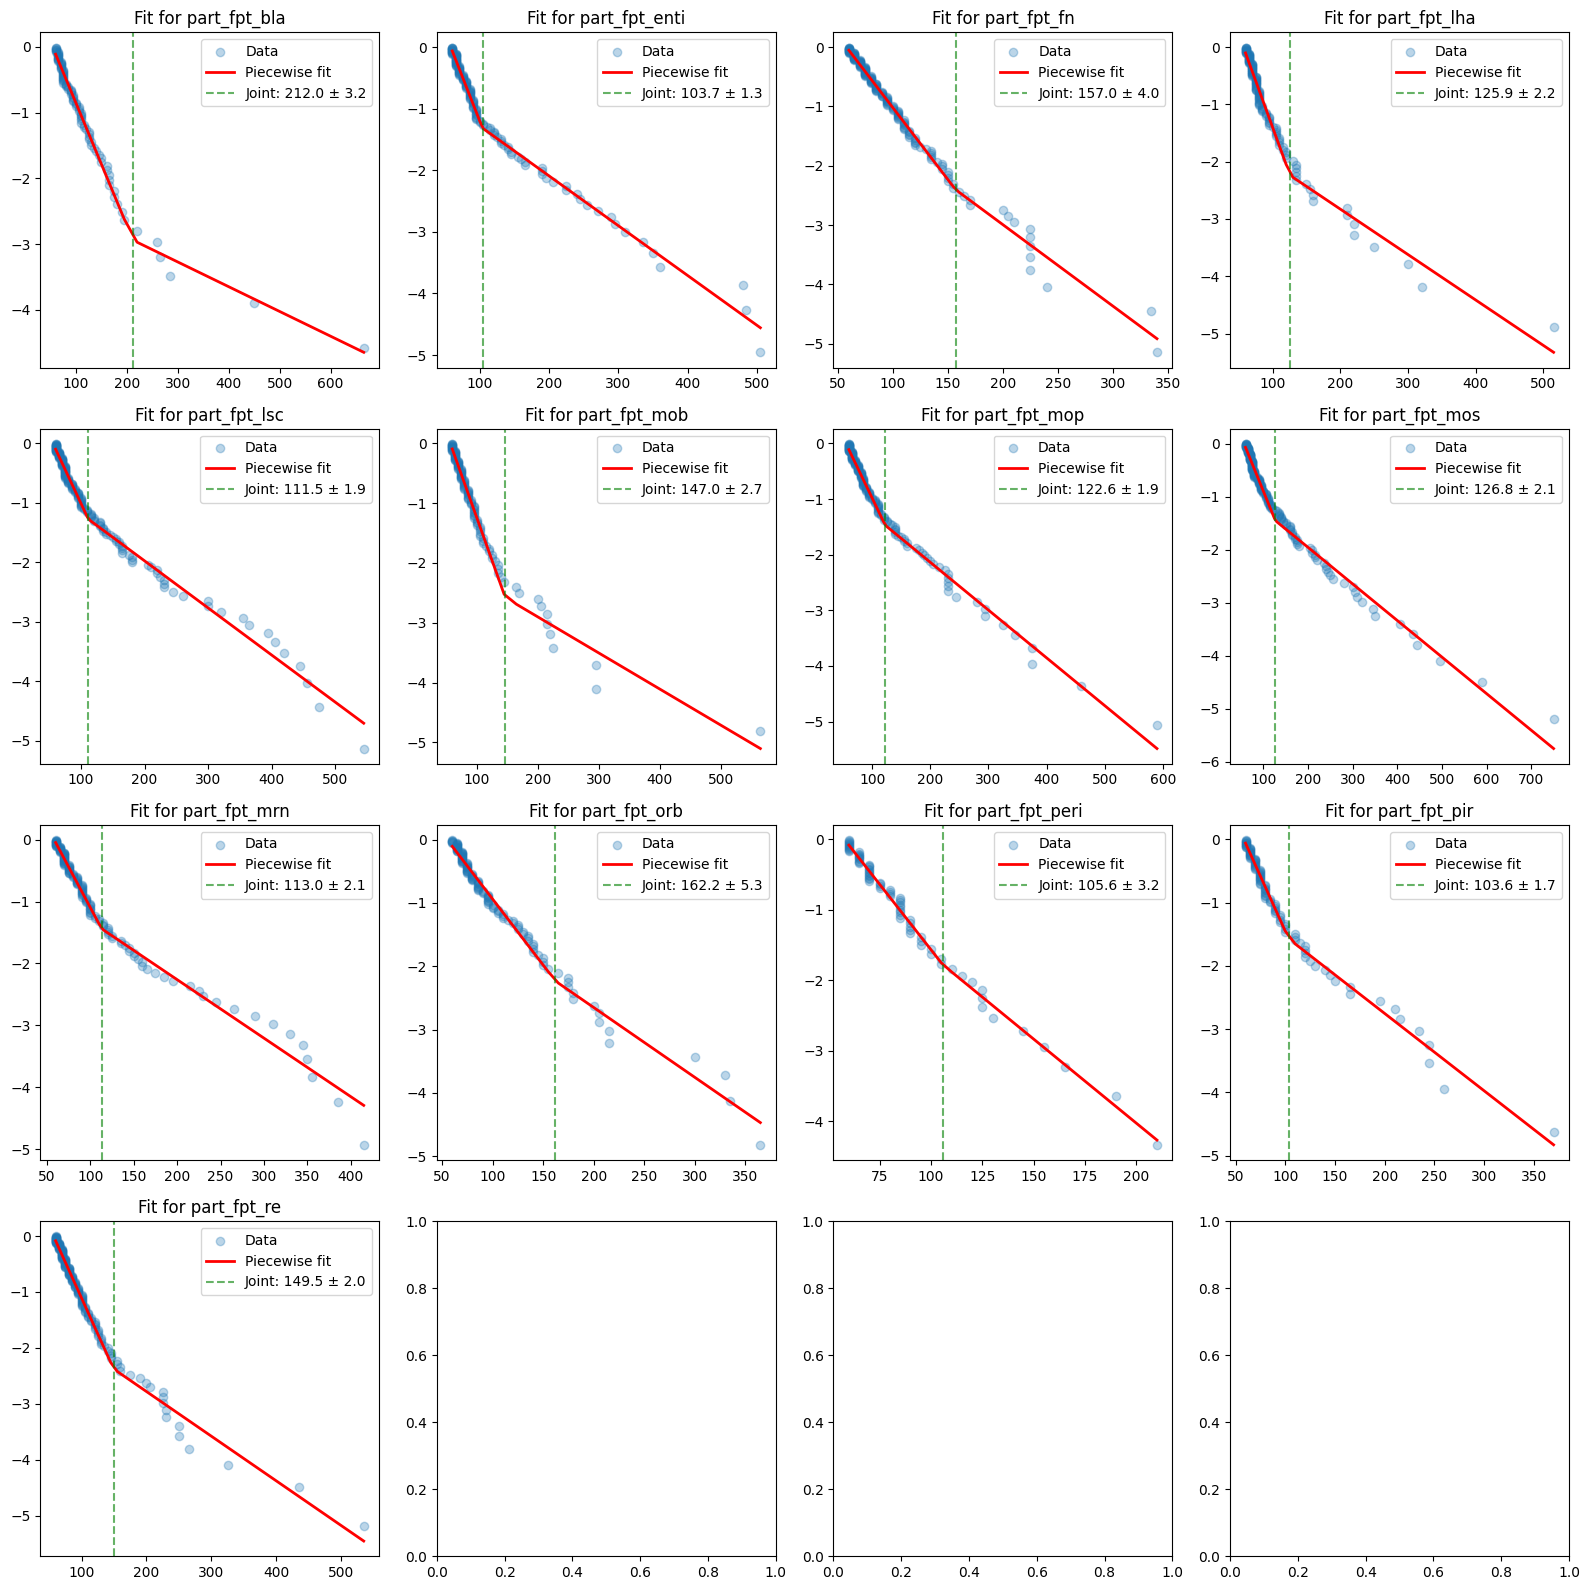

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_joint_se={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_st = [x for x in params[1]["s_t"] if 25 < x < 800]

    p = fit_piecewiseLinear(part_st, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_joint[nw] = p['joint']
    dict_joint_se[nw]=p['joint_se']
    dict_slp1_se[nw]=p['slopes_se'][0]

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


T test on early slope part st

In [ ]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -18.0172, P-value: 0.0000
T-statistic: 8.5253, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 13.4903, P-value: 0.0000
T-statistic: -2.9761, P-value: 0.0029
T-statistic: 8.6152, P-value: 0.0000
T-statistic: -6.5343, P-value: 0.0000
T-statistic: -8.8895, P-value: 0.0000
T-statistic: 3.5562, P-value: 0.0004
T-statistic: -8.1612, P-value: 0.0000
T-statistic: 19.1713, P-value: 0.0000
T-statistic: 14.9954, P-value: 0.0000
T-statistic: 3.7190, P-value: 0.0002


Compare joint

In [ ]:
jnw=[]
for s,se,label in zip(list(dict_joint.values()),list(dict_joint_se.values()),dict_joint.keys()):
    t, p = compare_slopes(dict_joint['fn'], dict_joint_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        jnw.append(label)
    else:
        pass

T-statistic: -10.6944, P-value: 0.0000
T-statistic: 12.7477, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 6.8454, P-value: 0.0000
T-statistic: 10.3379, P-value: 0.0000
T-statistic: 2.0917, P-value: 0.0365
T-statistic: 7.7915, P-value: 0.0000
T-statistic: 6.7014, P-value: 0.0000
T-statistic: 9.7623, P-value: 0.0000
T-statistic: -0.7722, P-value: 0.4400
T-statistic: 10.0702, P-value: 0.0000
T-statistic: 12.3283, P-value: 0.0000
T-statistic: 1.6968, P-value: 0.0897


In [21]:
part_st={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw,'s_j':jnw}


Data for figure 5j

In [ ]:
reader.data_dump_pkl('results/figures/fig5j_data.pkl',{'fpt_part':part_fpt,
                                                       'fpt_full':full_fpt,
                                                       'st_part':part_st})

In [23]:
full_fpt

{'slp1': {'bla': -0.0017281431470113047,
  'enti': -0.002480980665481094,
  'fn': -0.003485253030402766,
  'lha': -0.00202091068125252,
  'lsc': -0.0024360520271518356,
  'mob': -0.002258856297900321,
  'mop': -0.0036947221939079055,
  'mos': -0.00298577410027598,
  'mrn': -0.003135861469466485,
  'orb': -0.003042955468615255,
  'peri': -0.0010355558820930762,
  'pir': -0.0020175217649611413,
  're': -0.0030488011258202703},
 'bp': {'bla': 421.6843654753038,
  'enti': 365.1331639418863,
  'fn': 482.9726186813084,
  'lha': 420.32111158764405,
  'lsc': 402.3380491961294,
  'mob': 389.78049406563684,
  'mop': 502.6110711334354,
  'mos': 530.1868705323217,
  'mrn': 494.6867644434714,
  'orb': 405.7141639238101,
  'peri': 298.5746609123515,
  'pir': 321.2410918161189,
  're': 452.42547947589026},
 's_nw': ['bla', 'enti', 'lha', 'lsc', 'mob', 'peri', 'pir', 're'],
 's_j': ['bla',
  'enti',
  'lha',
  'lsc',
  'mob',
  'mop',
  'mos',
  'orb',
  'peri',
  'pir',
  're']}

For figure 6

### New Piecewise linear fit function which uses 'non linear' algorithm and gives error for all

In [ ]:

def fit_piecewiseLinear(data, ax, label):
    # 1. Prepare Data (CCDF logic)
    intervals = np.sort(data.copy())
    n = len(intervals)
    ccdf = 1.0 - np.arange(1, n + 1) / n
    mask = ccdf > 0
    x = intervals[mask]
    y = np.log(ccdf[mask])

    # 2. Fit the model
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breakpoints = my_pwlf.fit(2)  # [min_x, joint, max_x]
    joint = breakpoints[1]
    
    # 3. Calculate Joint Error (Standard Error of the breakpoint)
    # The 'non-linear' method treats the breakpoint as a parameter to find its SE
    try:
        se_all = my_pwlf.standard_errors(method='non-linear')
        se_joint = se_all[-1] # The last value is the SE of the interior joint
    except:
        se_joint = np.nan # Fallback if non-linear method isn't supported in your version

    # 4. Manually Construct Regression Matrix A
    # Column 0: Intercept (constant 1s)
    # Column 1: First slope component (x - min_x)
    # Column 2: Second slope component (x - joint, but only where x > joint)
    col0 = np.ones(len(x))
    col1 = x - breakpoints[0]
    col2 = np.maximum(0, x - joint)
    A = np.column_stack([col0, col1, col2])

    # 5. Calculate Slope Errors using Covariance
    # Degree of freedom = n_samples - n_parameters (3 for a 2-segment fit)
    dof = len(x) - 3
    sigma_sq = my_pwlf.ssr / dof
    
    # Covariance Matrix = sigma_sq * (A^T * A)^-1
    # pinv is used for numerical stability
    cov_beta = sigma_sq * linalg.pinv(np.dot(A.T, A))

    # Slope 1 = Beta 1
    se_slope1 = np.sqrt(cov_beta[1, 1])
    
    # Slope 2 = Beta 1 + Beta 2
    # Var(S2) = Var(B1) + Var(B2) + 2*Cov(B1, B2)
    var_slope2 = cov_beta[1, 1] + cov_beta[2, 2] + 2 * cov_beta[1, 2]
    se_slope2 = np.sqrt(max(0, var_slope2))

    # 6. Plotting and Results
    y_hat = my_pwlf.predict(x)
    slopes = my_pwlf.calc_slopes()

    ax.scatter(x, y, alpha=0.3, label="Data")
    ax.plot(x, y_hat, 'r', linewidth=2, label="Piecewise fit")
    ax.axvline(joint, color='green', linestyle='--', alpha=0.6, 
               label=f"Joint: {joint:.1f} ± {se_joint:.1f}")
    
    ax.set_title(f"Fit for {label}")
    ax.legend()

    print(f"--- Results for {label} ---")
    print(f"Joint:   {joint:.4f} ± {se_joint:.4f}")
    print(f"Slope 1: {slopes[0]:.4f} ± {se_slope1:.4f}")
    print(f"Slope 2: {slopes[1]:.4f} ± {se_slope2:.4f}")

    return {
        'slopes': slopes.tolist(),
        'slopes_se': [se_slope1, se_slope2],
        'joint': joint,
        'joint_se': se_joint
    }

1.part fpt

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_fpt_bla ---
Joint:   396.7403 ± 4.1881
Slope 1: -0.0028 ± 0.0001
Slope 2: -0.0167 ± 0.0005
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_fpt_enti ---
Joint:   525.8847 ± 2.1101
Slope 1: -0.0041 ± 0.0001
Slope 2: -0.0409 ± 0.0013
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_fpt_fn ---
Joint:   504.3588 ± 2.0566
Slope 1: -0.0043 ± 0.0001
Slope 2: -0.0335 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_fpt_lha ---
Joint:   526.3559 ± 3.0646
Slope 1: -0.0040 ± 0.0001
Slope 2: -0.0482 ± 0.0022
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_fpt_lsc ---
Joint:   526.4409 ± 1.3936
Slope 1: -0.0047 ± 0.0001
Slope 2: -0.0521 ± 0.0015
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

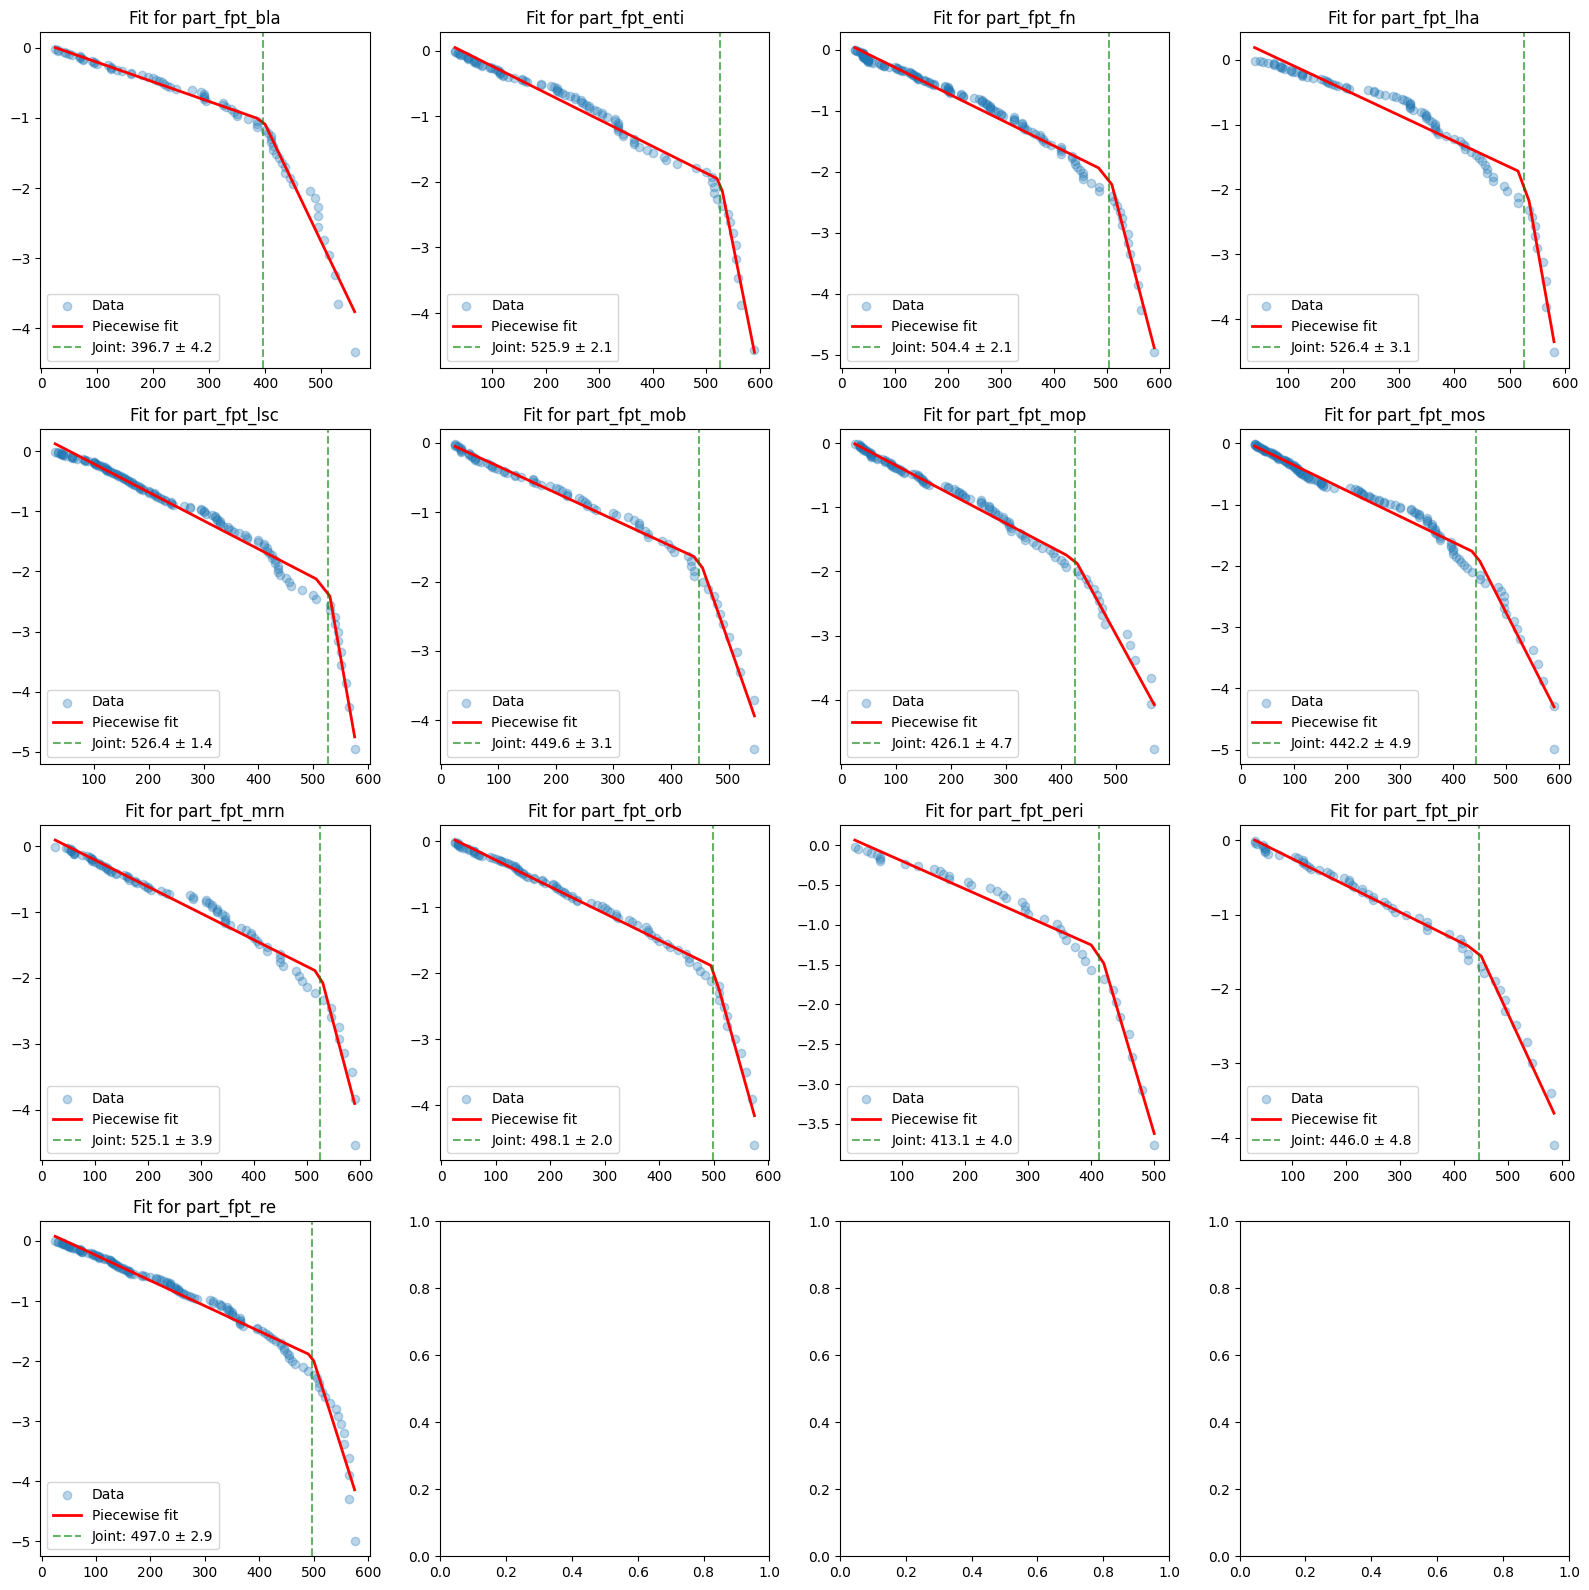

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}




for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_fpt = [x for x in params[1]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(part_fpt, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']
    
   
    

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [ ]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_pfpt = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_pfpt)


          exp1   exp1_se      exp2   exp2_se       joint  joint_se
bla  -0.002797  0.000133 -0.016716  0.000455  396.740316  4.188144
enti -0.004069  0.000077 -0.040917  0.001275  525.884725  2.110061
fn   -0.004289  0.000063 -0.033457  0.000797  504.358809  2.056586
lha  -0.004007  0.000134 -0.048249  0.002172  526.355858  3.064559
lsc  -0.004737  0.000068 -0.052077  0.001459  526.440889  1.393626
mob  -0.003831  0.000079 -0.023689  0.000613  449.587886  3.071854
mop  -0.004507  0.000083 -0.015716  0.000397  426.101000  4.660612
mos  -0.004189  0.000079 -0.016997  0.000423  442.233661  4.911724
mrn  -0.004040  0.000100 -0.030479  0.001212  525.104515  3.892550
orb  -0.004040  0.000060 -0.029434  0.000665  498.143891  2.036277
peri -0.003508  0.000155 -0.026694  0.001042  413.061659  3.996742
pir  -0.003596  0.000095 -0.015652  0.000443  445.993106  4.777063
re   -0.004215  0.000082 -0.028612  0.000832  496.997654  2.894362


2. Full FPT

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for full_fpt_bla ---
Joint:   421.7124 ± 8.6597
Slope 1: -0.0017 ± 0.0007
Slope 2: -0.0156 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for full_fpt_enti ---
Joint:   365.1414 ± 7.7418
Slope 1: -0.0025 ± 0.0002
Slope 2: -0.0119 ± 0.0004
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for full_fpt_fn ---
Joint:   482.9871 ± 4.9613
Slope 1: -0.0035 ± 0.0002
Slope 2: -0.0238 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for full_fpt_lha ---
Joint:   420.3292 ± 9.3848
Slope 1: -0.0020 ± 0.0003
Slope 2: -0.0166 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for full_fpt_lsc ---
Joint:   402.3691 ± 5.6165
Slope 1: -0.0024 ± 0.0002
Slope 2: -0.0166 ± 0.0006
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

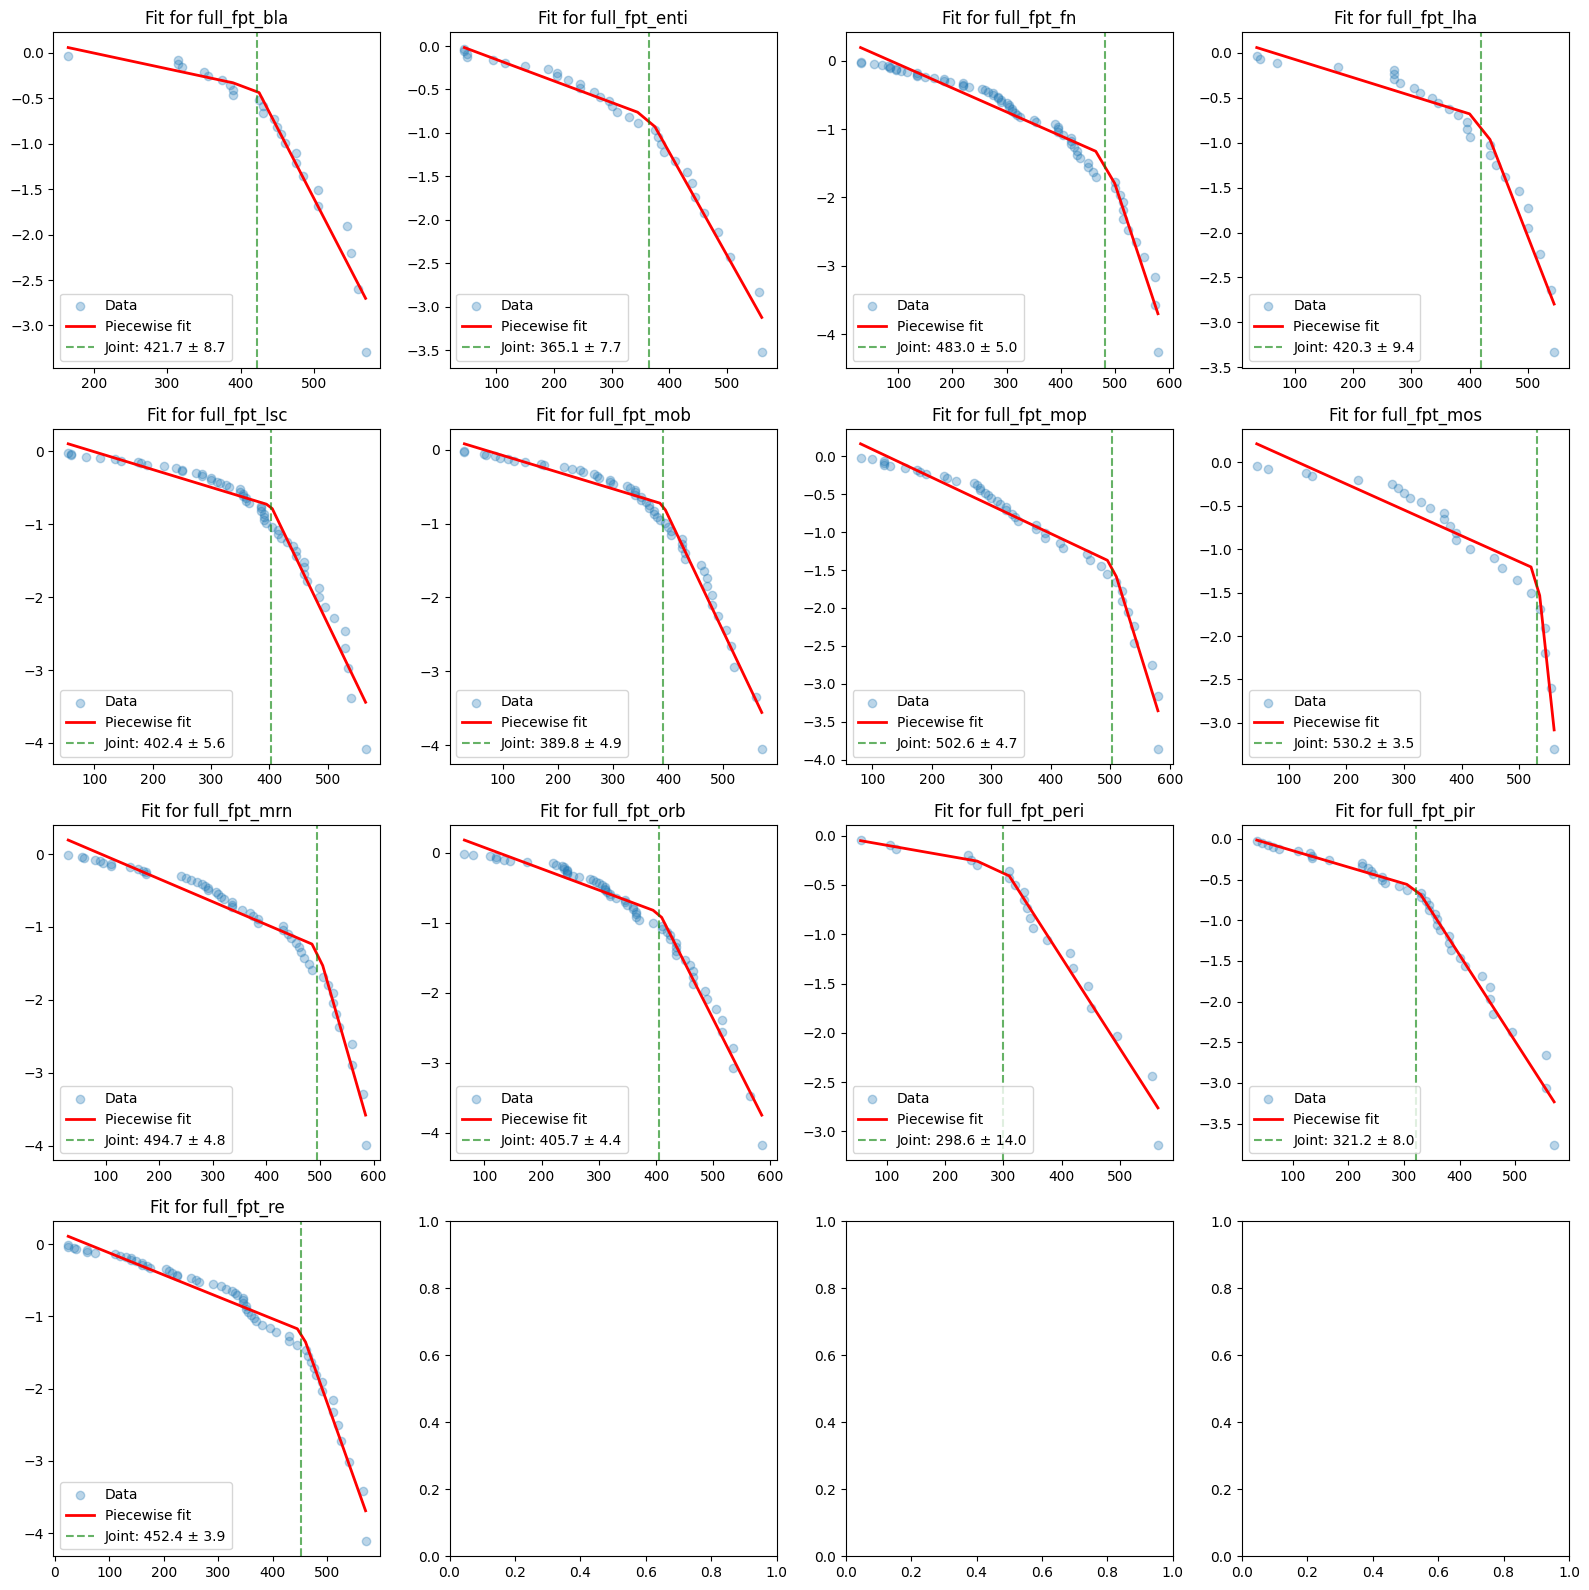

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()


# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_fpt = [x for x in params[2]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(full_fpt, ax, f"full_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [ ]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_ffpt = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_ffpt)


          exp1   exp1_se      exp2   exp2_se       joint   joint_se
bla  -0.001730  0.000671 -0.015623  0.000799  421.712372   8.659692
enti -0.002481  0.000204 -0.011871  0.000413  365.141355   7.741776
fn   -0.003485  0.000151 -0.023829  0.000952  482.987118   4.961267
lha  -0.002021  0.000343 -0.016642  0.001013  420.329165   9.384773
lsc  -0.002437  0.000232 -0.016601  0.000557  402.369144   5.616466
mob  -0.002259  0.000184 -0.015650  0.000442  389.799597   4.902268
mop  -0.003695  0.000181 -0.025236  0.001226  502.634959   4.708141
mos  -0.002986  0.000286 -0.061911  0.005164  530.188316   3.459317
mrn  -0.003136  0.000162 -0.025646  0.001090  494.706235   4.836226
orb  -0.003043  0.000189 -0.016159  0.000418  405.700682   4.416402
peri -0.001037  0.000426 -0.009226  0.000368  298.604932  14.014841
pir  -0.002018  0.000231 -0.010620  0.000312  321.247569   7.990682
re   -0.003049  0.000133 -0.021234  0.000669  452.418494   3.905615


3. Part ST

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_st_bla ---
Joint:   212.0178 ± 3.2484
Slope 1: -0.0186 ± 0.0002
Slope 2: -0.0038 ± 0.0002
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_st_enti ---
Joint:   103.7203 ± 1.2624
Slope 1: -0.0287 ± 0.0005
Slope 2: -0.0081 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_st_fn ---
Joint:   157.0617 ± 3.9871
Slope 1: -0.0242 ± 0.0003
Slope 2: -0.0137 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_st_lha ---
Joint:   125.9111 ± 2.1866
Slope 1: -0.0324 ± 0.0006
Slope 2: -0.0079 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_st_lsc ---
Joint:   111.4941 ± 1.8732
Slope 1: -0.0228 ± 0.0004
Slope 2: -0.0079 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--- Res

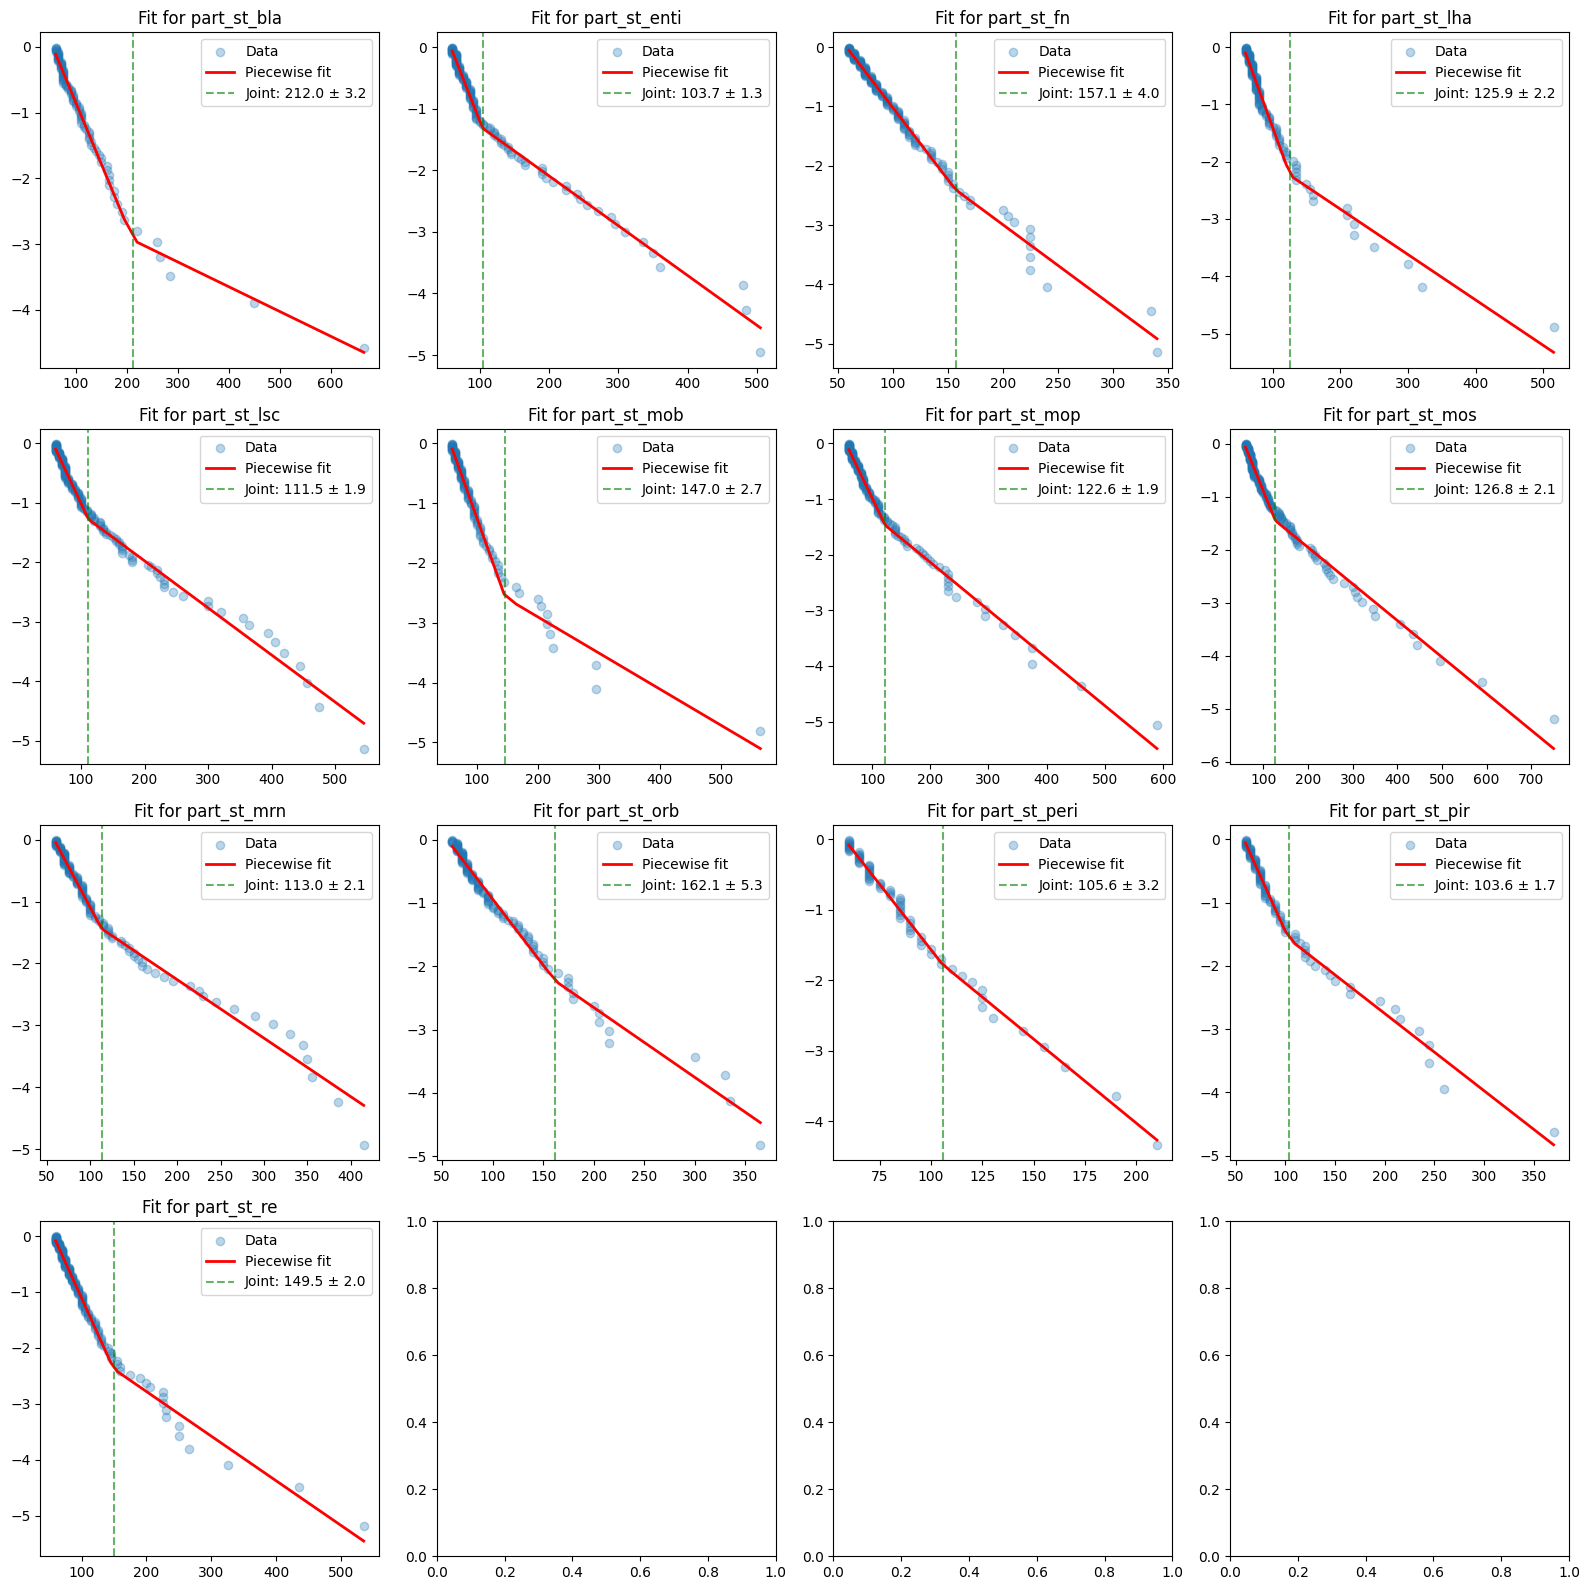

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_st = [x for x in params[1]["s_t"] if 25 < x < 800]

    p = fit_piecewiseLinear(part_st, ax, f"part_st_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [ ]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_pst = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_pst)


          exp1   exp1_se      exp2   exp2_se       joint  joint_se
bla  -0.018615  0.000184 -0.003764  0.000155  212.017754  3.248383
enti -0.028659  0.000452 -0.008081  0.000099  103.720253  1.262362
fn   -0.024243  0.000252 -0.013738  0.000324  157.061747  3.987094
lha  -0.032447  0.000553 -0.007936  0.000275  125.911062  2.186619
lsc  -0.022842  0.000398 -0.007914  0.000101  111.494086  1.873198
mob  -0.028581  0.000436 -0.006034  0.000267  147.008078  2.668664
mop  -0.021730  0.000291 -0.008588  0.000106  122.588048  1.909420
mos  -0.020672  0.000313 -0.006895  0.000094  126.829931  2.104330
mrn  -0.026261  0.000508 -0.009444  0.000165  112.990676  2.110576
orb  -0.020827  0.000335 -0.011020  0.000361  162.115232  5.281181
peri -0.037068  0.000620 -0.023833  0.000551  105.644047  3.185576
pir  -0.034770  0.000655 -0.012223  0.000248  103.587613  1.703527
re   -0.025588  0.000259 -0.007972  0.000177  149.462158  2.019136


Storing data for figure 6 all lastparams

In [14]:
reader.data_dump_pkl('results/figures/fig6_data.pkl',{'full_fpt':df_ffpt,'part_fpt':df_pfpt,'part_st':df_pst})

4. Full st

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for full_st_bla ---
Joint:   277.6409 ± 0.0001
Slope 1: -0.0125 ± 0.0012
Slope 2: -0.0460 ± 0.0201
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for full_st_enti ---
Joint:   505.0000 ± 16.8357
Slope 1: -0.0035 ± 0.0002
Slope 2: -0.0098 ± 0.0007
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for full_st_fn ---
Joint:   125.0869 ± 0.0852
Slope 1: 0.8154 ± 0.7973
Slope 2: -0.0059 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for full_st_lha ---
Joint:   240.5655 ± 12.8280
Slope 1: -0.0187 ± 0.0009
Slope 2: -0.0066 ± 0.0011
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for full_st_lsc ---
Joint:   323.1424 ± 3.5884
Slope 1: -0.0068 ± 0.0005
Slope 2: -0.0693 ± 0.0077
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--- Re

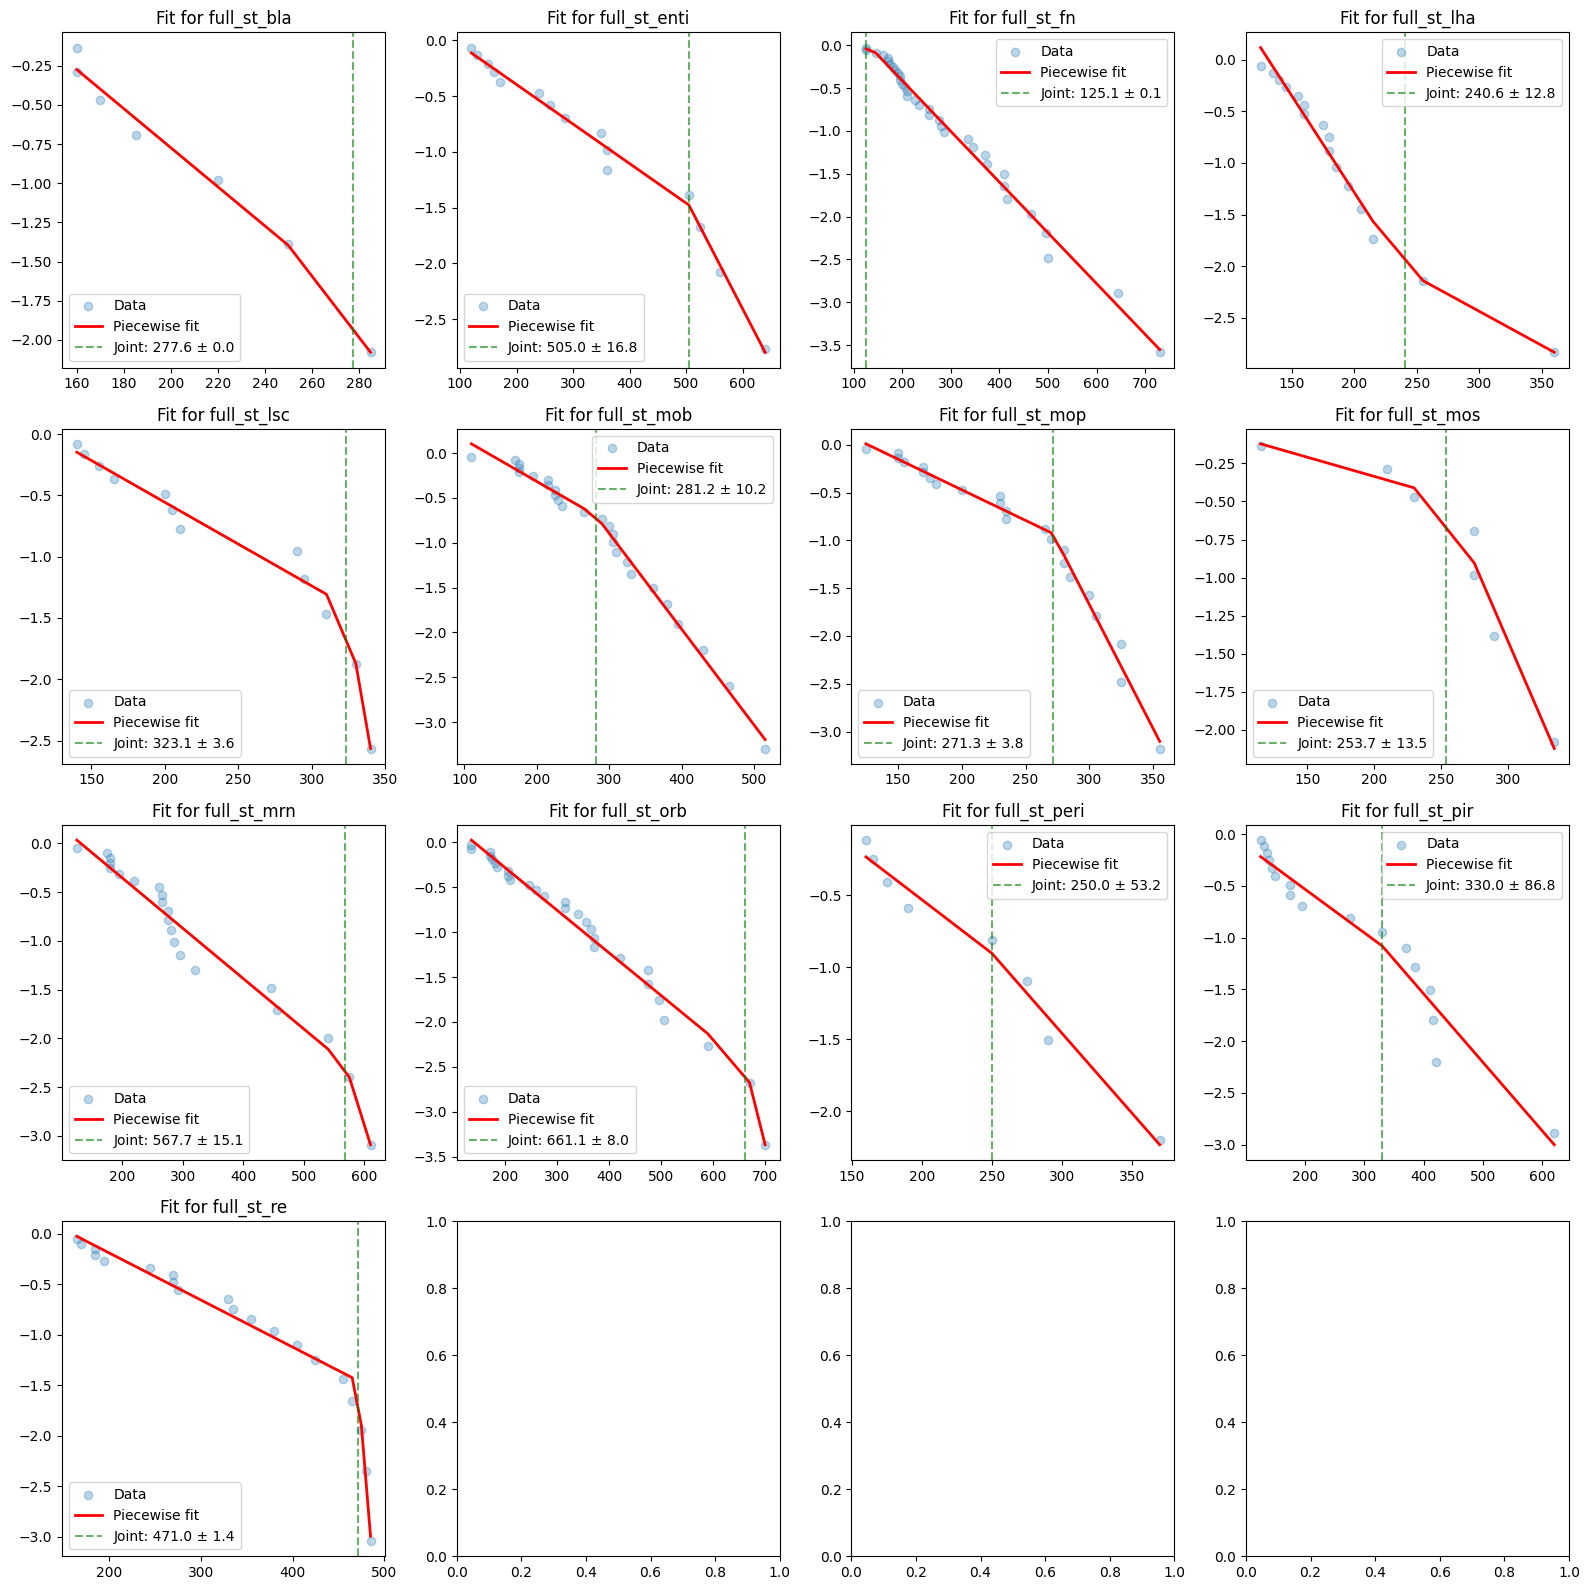

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))
# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}
# Flatten axes for easy iteration
axes = axes.flatten()

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_st = [x for x in params[2]["s_t"] if 25 < x < 800]

    

    nw = file.split('_')[-1].split('.')[-2]

    p=fit_piecewiseLinear(full_st, ax, f'full_st_{nw}')

    

    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']
    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [ ]:
df_fst = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_fst)

          exp1   exp1_se      exp2   exp2_se       joint   joint_se
bla  -0.012470  0.001194 -0.045982  0.020125  277.640856   0.000110
enti -0.003544  0.000178 -0.009788  0.000717  505.000000  16.835718
fn    0.815364  0.797347 -0.005918  0.000112  125.086875   0.085218
lha  -0.018699  0.000930 -0.006601  0.001099  240.565457  12.827959
lsc  -0.006816  0.000536 -0.069314  0.007704  323.142440   3.588369
mob  -0.004657  0.000372 -0.010709  0.000286  281.247112  10.218372
mop  -0.006416  0.000448 -0.025989  0.001004  271.291342   3.830450
mos  -0.002516  0.001430 -0.020338  0.002487  253.676178  13.497205
mrn  -0.005166  0.000300 -0.019787  0.004329  567.700775  15.112947
orb  -0.004741  0.000142 -0.023103  0.002966  661.142373   8.032482
peri -0.007431  0.001346 -0.011078  0.001356  250.000000  53.188863
pir  -0.004212  0.000671 -0.006624  0.000826  330.000000  86.804406
re   -0.004665  0.000222 -0.109868  0.006778  470.963005   1.373116


In [23]:
data_d=reader.data_read_bz2('results/figures/fig4d_data.pkl')
data_d

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
bla,0.946027,0.790222,1.315748,0.679832,2.293980,0.569710,0.404481,0.030669,0.769758,0.501367,...,0.587057,0.108361,1.098843,1.145185,1.318454,0.720158,1.544235,0.595067,0.578058,0.046287
enti,1.257179,0.599361,1.439222,0.661568,2.186557,0.454208,0.401906,0.041159,1.039782,0.434212,...,0.515478,0.082343,1.255840,0.933083,1.376045,0.728862,1.576173,0.519163,0.610834,0.055703
fn,0.993989,0.678284,1.416082,0.684669,2.423625,0.511457,0.291894,0.019842,0.691751,0.350546,...,0.374762,0.142710,1.173763,0.946917,1.328486,0.723473,1.790217,0.528919,0.508224,0.037680
lha,1.093092,0.685441,1.320350,0.570927,2.502703,0.512058,0.315430,0.024017,0.910082,0.345501,...,0.553347,0.096767,1.141286,0.921314,1.302976,0.678812,2.016950,0.501724,0.436939,0.030026
lsc,1.002861,0.575773,1.367462,0.706469,2.547664,0.492780,0.306991,0.024914,0.808391,0.417801,...,0.315441,0.017996,1.251526,0.961880,1.348677,0.652408,1.754532,0.466562,0.564414,0.038604
mob,0.979523,0.712642,1.321307,0.873694,2.101735,0.639470,0.371628,0.030643,0.671688,0.453883,...,0.448612,0.058341,1.125194,0.901966,1.365013,0.794217,1.763736,0.559007,0.490867,0.039692
mop,0.821761,0.610196,1.240884,0.723040,2.778786,0.538973,0.286359,0.015224,0.692878,0.412196,...,0.192013,0.030234,1.057835,0.957098,1.378036,0.701050,1.908680,0.509044,0.488258,0.029592
mos,0.835596,0.598804,1.162153,0.805413,2.700909,0.627684,0.269439,0.014000,0.518986,0.367910,...,0.304861,0.030780,0.970222,1.029197,1.154940,0.861050,1.791578,0.629859,0.563154,0.040951
mrn,0.911909,0.596253,1.316891,0.808545,2.593021,0.513201,0.260179,0.015049,0.713710,0.532160,...,0.403055,0.041081,1.018145,0.960861,1.286125,0.785019,1.933662,0.583094,0.433095,0.026338
orb,1.037653,0.582054,1.283048,0.737487,2.472195,0.546333,0.341231,0.027185,0.697519,0.396727,...,0.421390,0.034539,1.211736,0.955023,1.276472,0.673382,1.833163,0.539118,0.511106,0.036400


<Axes: >

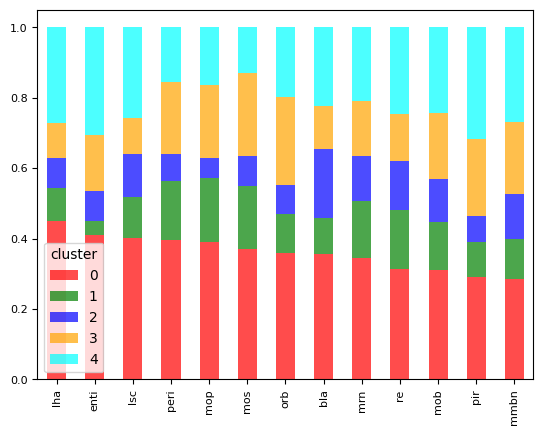

In [21]:
colors=['red','green','blue','orange','cyan']
data_b=data_b.rename(columns={'fn':'mmbn'}).T
data_b=data_b.sort_values(by=0,ascending=False)
data_b.plot(kind='bar',color=colors, stacked=True,alpha=0.7,fontsize=8)

In [22]:
data_b

cluster,0,1,2,3,4
lha,0.450000,0.092857,0.085714,0.100000,0.271429
enti,0.410596,0.039735,0.086093,0.158940,0.304636
lsc,0.401070,0.117647,0.122995,0.101604,0.256684
peri,0.397436,0.166667,0.076923,0.205128,0.153846
mop,0.390244,0.182927,0.054878,0.207317,0.164634
mos,0.370968,0.177419,0.086022,0.236559,0.129032
orb,0.360294,0.110294,0.080882,0.250000,0.198529
bla,0.355140,0.102804,0.196262,0.121495,0.224299
mrn,0.344595,0.162162,0.128378,0.155405,0.209459
re,0.315000,0.165000,0.140000,0.135000,0.245000
